In [ ]:
from datasets import load_dataset

# Load everything
dataset = load_dataset("coastalcph/multi_eurlex", "all_languages")

# Save it
dataset.save_to_disk("./data/multi_eurlex")

print("Done!")

Download Dataset.

In [ ]:
import shutil
import os
from datasets import load_dataset

# Clear cache
cache_path = os.path.expanduser("~/.cache/huggingface/datasets/coastalcph___multi_eurlex")
if os.path.exists(cache_path):
    shutil.rmtree(cache_path)
    print("✓ Cleared cache")

# Download and save
print("\nDownloading dataset...")
dataset = load_dataset("coastalcph/multi_eurlex", "all_languages", trust_remote_code=True)

print("\nSaving to ./data/multi_eurlex...")
dataset.save_to_disk("./data/multi_eurlex")

print("\n✅ DONE!")

Successful loading of dataset from disk.

In [2]:
from datasets import load_from_disk

# Load in ~5 seconds
dataset = load_from_disk("./data/multi_eurlex")

print(f"Train: {len(dataset['train']):,} examples")
print(f"Validation: {len(dataset['validation']):,} examples")
print(f"Test: {len(dataset['test']):,} examples")

Train: 55,000 examples
Validation: 5,000 examples
Test: 5,000 examples


Successful loading of dataset from disk

In [1]:
from datasets import load_from_disk

# Load all splits at once
dataset = load_from_disk('/Users/vincent/masters-thesis/data/multi_eurlex')

# Access each split
train_data = dataset['train']
val_data = dataset['validation']
test_data = dataset['test']

# Explore
print(train_data)
print(train_data[0])  # First example

Dataset({
    features: ['celex_id', 'text', 'labels'],
    num_rows: 55000
})
{'celex_id': '32006D0213', 'text': {'bg': '32006D0213\nL 079/27\nОФИЦИАЛЕН ВЕСТНИК НА ЕВРОПЕЙСКИЯ СЪЮЗ\nРЕШЕНИЕ НА КОМИСИЯТА\nот 6 март 2006 година\nотносно класификацията на характеристиките по реакция на огън на някои строителни материали за подови настилки от дървесина, ламперии и външни стенни покрития от масивна дървесина\n(нотифицирано под номер C(2006) 655)\n(текст от значение за ЕИП)\n(2006/213/ЕО)\nКОМИСИЯТА НА ЕВРОПЕЙСКИТЕ ОБЩНОСТИ,\nкато взе предвид Договора за създаване на Европейската общност,\nкато взе предвид Директива 89/106/ЕИО на Съвета от 21 декември 1988 г. относно сближаването на законовите, подзаконовите и административните разпоредби на държавите-членки по отношение на строителните продукти (1), и по-специално член 20, параграф 2 от нея,\nкато има предвид, че:\n(1)\nДиректива 89/106/ЕИО приема, че за да се вземе предвид разликата в нивата на защита, които съществуват на национално, рег

Analyzing Dataset with pandas.

In [4]:
import pandas as pd
from datasets import load_from_disk

# Load the dataset
dataset = load_from_disk('/Users/vincent/masters-thesis/data/multi_eurlex')

# Look at test split
test_data = dataset['test']
print(f"Test set has {len(test_data)} documents")

# Look at one example
example = test_data[0]
print(f"Document ID: {example['celex_id']}")
print(f"Categories: {example['labels']}")
print(f"Available languages: {list(example['text'].keys())}")
print(f"\nEnglish preview (first 500 chars):")
print(example['text']['en'][:500])

# Check label distribution
all_labels = [label for doc in test_data for label in doc['labels']]
print(f"\nTotal label occurrences: {len(all_labels)}")
print(f"Unique categories: {len(set(all_labels))}")

Test set has 5000 documents
Document ID: 32013R1390
Categories: [18, 15, 5, 6]
Available languages: ['bg', 'cs', 'da', 'de', 'el', 'en', 'es', 'et', 'fi', 'fr', 'hr', 'hu', 'it', 'lt', 'lv', 'mt', 'nl', 'pl', 'pt', 'ro', 'sk', 'sl', 'sv']

English preview (first 500 chars):
COUNCIL REGULATION (EU) No 1390/2013
of 16 December 2013
on the allocation of fishing opportunities under the Protocol agreed between the European Union and the Union of the Comoros setting out the fishing opportunities and financial contribution provided for in the Fisheries Partnership Agreement currently in force between the two parties
THE COUNCIL OF THE EUROPEAN UNION,
Having regard to the Treaty on the Functioning of the European Union, and in particular Article 43(3) thereof,
Having regar

Total label occurrences: 17969
Unique categories: 21


Single Document in multiple languages

In [14]:
from datasets import load_from_disk

dataset = load_from_disk('/Users/vincent/masters-thesis/data/multi_eurlex')
train_data = dataset['train']

# Get one document
doc = train_data[0]

print("=" * 80)
print(f"Document ID: {doc['celex_id']}")
print(f"Belongs to categories: {doc['labels']}")
print("=" * 80)

# Show the same document in English and German
print("\n🇬🇧 ENGLISH VERSION (first 300 chars):")
print(doc['text']['en'][:300])
print("...")

print("\n🇩🇪 GERMAN VERSION (first 300 chars):")
print(doc['text']['de'][:300])
print("...")

print("\n🇫🇷 FRENCH VERSION (first 300 chars):")
print(doc['text']['fr'][:300])
print("...")

Document ID: 32006D0213
Belongs to categories: [1, 20, 7, 3, 0]

🇬🇧 ENGLISH VERSION (first 300 chars):
COMMISSION DECISION
of 6 March 2006
establishing the classes of reaction-to-fire performance for certain construction products as regards wood flooring and solid wood panelling and cladding
(notified under document number C(2006) 655)
(Text with EEA relevance)
(2006/213/EC)
THE COMMISSION OF THE EUR
...

🇩🇪 GERMAN VERSION (first 300 chars):
ENTSCHEIDUNG DER KOMMISSION
vom 6. März 2006
zur Festlegung der Brandverhaltensklassen für bestimmte Bauprodukte (Holzfußböden sowie Wand- und Deckenbekleidungen aus Massivholz)
(Bekannt gegeben unter Aktenzeichen K(2006) 655)
(Text von Bedeutung für den EWR)
(2006/213/EG)
DIE KOMMISSION DER EUROPÄI
...

🇫🇷 FRENCH VERSION (first 300 chars):
DÉCISION DE LA COMMISSION
du 6 mars 2006
établissant la classification des caractéristiques de réaction au feu de certains produits de construction pour ce qui concerne les sols en bois et les lambris et revêtem

Compare multiple documents side by side

In [10]:
# Look at first 3 documents
print("\n" + "=" * 80)
print("COMPARING MULTIPLE DOCUMENTS")
print("=" * 80)

for i in range(3):
    doc = test_data[i]
    print(f"\nDocument {i+1}:")
    print(f"  ID: {doc['celex_id']}")
    print(f"  Categories: {doc['labels']}")
    print(f"  English preview: {doc['text']['en'][:150]}...")
    print()


COMPARING MULTIPLE DOCUMENTS

Document 1:
  ID: 32013R1390
  Categories: [18, 15, 5, 6]
  English preview: COUNCIL REGULATION (EU) No 1390/2013
of 16 December 2013
on the allocation of fishing opportunities under the Protocol agreed between the European Uni...


Document 2:
  ID: 32015R0176
  Categories: [3, 17, 18]
  English preview: COMMISSION IMPLEMENTING REGULATION (EU) 2015/176
of 5 February 2015
Approving non-minor amendments to the specification for a name entered in the regi...


Document 3:
  ID: 32015R0596
  Categories: [1, 17, 20, 0, 6, 18]
  English preview: COMMISSION IMPLEMENTING REGULATION (EU) 2015/596
of 15 April 2015
amending Regulation (EC) No 606/2009 as regards the increase in the maximum total su...



Explore the label distribution

In [15]:
from collections import Counter

# Collect all labels
all_labels = []
for doc in test_data:
    all_labels.extend(doc['labels'])

# Count occurrences
label_counts = Counter(all_labels)

print("\n" + "=" * 80)
print("TOP 10 MOST COMMON CATEGORIES")
print("=" * 80)
for label, count in label_counts.most_common(10):
    print(f"Category {label}: {count} documents")

print(f"\nTotal unique categories: {len(label_counts)}")
print(f"Average labels per document: {len(all_labels) / len(test_data):.2f}")


TOP 10 MOST COMMON CATEGORIES
Category 3: 2769 documents
Category 18: 2208 documents
Category 6: 1960 documents
Category 17: 1641 documents
Category 15: 1347 documents
Category 5: 1086 documents
Category 2: 974 documents
Category 0: 774 documents
Category 1: 653 documents
Category 7: 622 documents

Total unique categories: 21
Average labels per document: 3.59


Find Documents with specific properties

In [16]:
# Find documents with exactly 3 labels
docs_with_3_labels = [doc for doc in test_data if len(doc['labels']) == 3]
print(f"\n{len(docs_with_3_labels)} documents have exactly 3 labels")

# Find documents in category 1
docs_in_category_1 = [doc for doc in test_data if 1 in doc['labels']]
print(f"{len(docs_in_category_1)} documents are in category 1")

# Show one example
if docs_in_category_1:
    example = docs_in_category_1[0]
    print(f"\nExample from category 1:")
    print(f"  ID: {example['celex_id']}")
    print(f"  All categories: {example['labels']}")
    print(f"  Text (first 200 chars): {example['text']['en'][:200]}...")


1499 documents have exactly 3 labels
653 documents are in category 1

Example from category 1:
  ID: 32015R0596
  All categories: [1, 17, 20, 0, 6, 18]
  Text (first 200 chars): COMMISSION IMPLEMENTING REGULATION (EU) 2015/596
of 15 April 2015
amending Regulation (EC) No 606/2009 as regards the increase in the maximum total sulphur dioxide content where the climate conditions...


Compare document lengths across languages

In [17]:
# Compare text lengths for one document
doc = test_data[0]

print("\n" + "=" * 80)
print("TEXT LENGTH COMPARISON ACROSS LANGUAGES")
print("=" * 80)

lengths = {}
for lang, text in doc['text'].items():
    lengths[lang] = len(text)

# Sort by length
sorted_lengths = sorted(lengths.items(), key=lambda x: x[1], reverse=True)

for lang, length in sorted_lengths[:10]:
    print(f"{lang.upper()}: {length:,} characters")


TEXT LENGTH COMPARISON ACROSS LANGUAGES
NL: 3,834 characters
DE: 3,728 characters
MT: 3,720 characters
ES: 3,695 characters
EL: 3,683 characters
RO: 3,613 characters
IT: 3,611 characters
FR: 3,582 characters
BG: 3,534 characters
PT: 3,510 characters


##### Simple dataframe view

In [20]:
import pandas as pd

# Create a simplified view - use .select() instead of slicing
data_for_df = []
for i in range(10):  # First 10 docs
    doc = test_data[i]  # Access one document at a time
    data_for_df.append({
        'index': i,
        'doc_id': doc['celex_id'],
        'num_labels': len(doc['labels']),
        'labels': str(doc['labels']),
        'en_text_preview': doc['text']['en'][:100] + "...",
        'text_length_en': len(doc['text']['en'])
    })

df = pd.DataFrame(data_for_df)
print("\n" + "=" * 80)
print("DATAFRAME VIEW OF FIRST 10 DOCUMENTS")
print("=" * 80)
print(df.to_string())


DATAFRAME VIEW OF FIRST 10 DOCUMENTS
   index      doc_id  num_labels                    labels                                                                                            en_text_preview  text_length_en
0      0  32013R1390           4            [18, 15, 5, 6]  COUNCIL REGULATION (EU) No 1390/2013\nof 16 December 2013\non the allocation of fishing opportunities ...            3410
1      1  32015R0176           3               [3, 17, 18]  COMMISSION IMPLEMENTING REGULATION (EU) 2015/176\nof 5 February 2015\nApproving non-minor amendments t...            1790
2      2  32015R0596           6     [1, 17, 20, 0, 6, 18]  COMMISSION IMPLEMENTING REGULATION (EU) 2015/596\nof 15 April 2015\namending Regulation (EC) No 606/20...            2907
3      3  32015D0041           7  [2, 1, 19, 5, 9, 18, 15]  DECISION (EU) 2015/41 OF THE EUROPEAN PARLIAMENT AND OF THE COUNCIL\nof 17 December 2014\non the mobil...            3041
4      4  32013D0785           4            [18, 15,

##### Visual summary


Saved label distribution plot as 'label_distribution.png'
Saved labels per document plot as 'labels_per_doc.png'


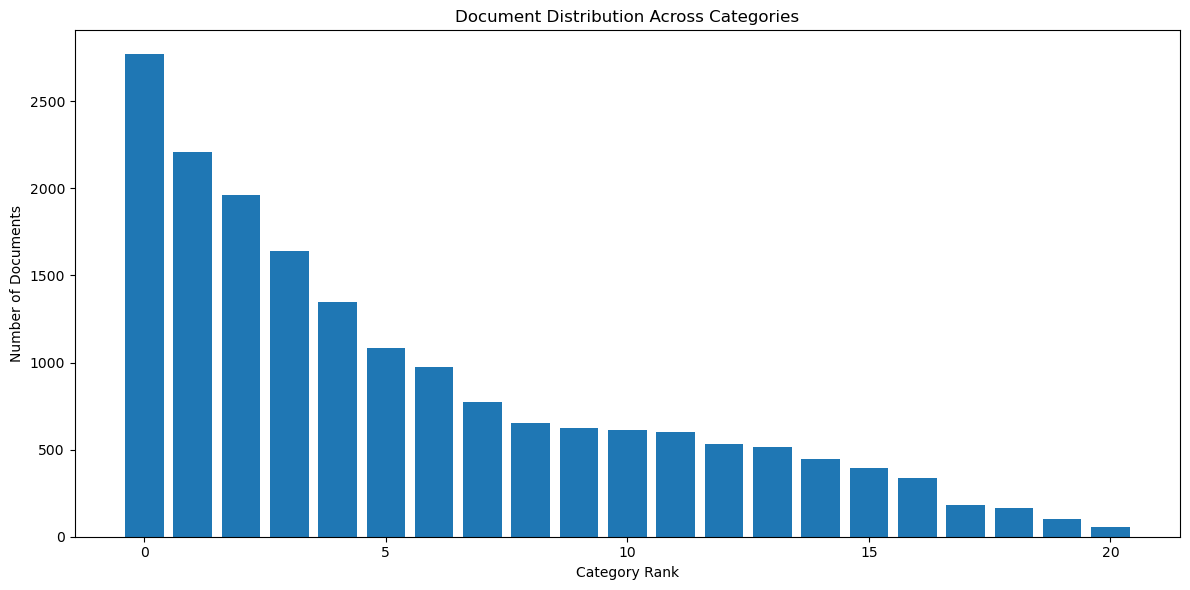

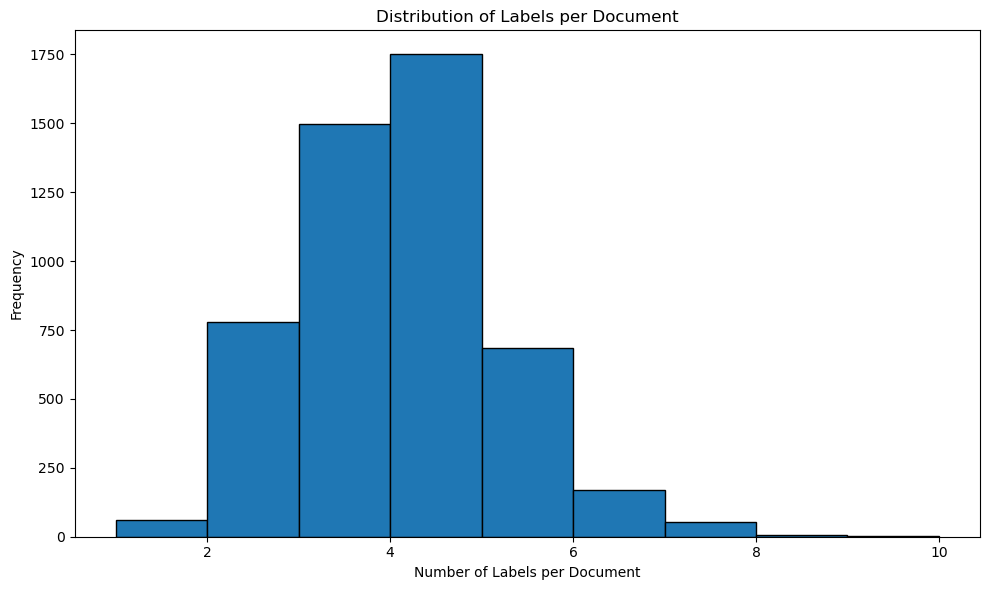

In [ ]:
import matplotlib.pyplot as plt

# Label distribution histogram
label_counts = Counter(all_labels)
plt.figure(figsize=(12, 6))
plt.bar(range(len(label_counts)), sorted(label_counts.values(), reverse=True))
plt.xlabel('Category Rank')
plt.ylabel('Number of Documents')
plt.title('Document Distribution Across Categories')
plt.tight_layout()
plt.savefig('label_distribution.png')
print("\nSaved label distribution plot as 'label_distribution.png'")

# Number of labels per document
labels_per_doc = [len(doc['labels']) for doc in test_data]
plt.figure(figsize=(10, 6))
plt.hist(labels_per_doc, bins=range(1, max(labels_per_doc)+2), edgecolor='black')
plt.xlabel('Number of Labels per Document')
plt.ylabel('Frequency')
plt.title('Distribution of Labels per Document')
plt.tight_layout()
# plt.savefig('labels_per_doc.png')
print("Saved labels per document plot as 'labels_per_doc.png'")

##### Simple list of all unique labels

In [21]:
# Get all unique labels in the dataset
all_labels = set()
for doc in test_data:
    all_labels.update(doc['labels'])

all_labels_sorted = sorted(all_labels)
print(f"Total unique labels: {len(all_labels_sorted)}")
print(f"All labels: {all_labels_sorted}")

Total unique labels: 21
All labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [22]:
# Check across all splits
def count_unique_labels(split):
    labels = set()
    for doc in split:
        labels.update(doc['labels'])
    return labels

train_labels = count_unique_labels(dataset['train'])
val_labels = count_unique_labels(dataset['validation'])
test_labels = count_unique_labels(dataset['test'])

print(f"Train: {len(train_labels)} unique labels")
print(f"Val: {len(val_labels)} unique labels") 
print(f"Test: {len(test_labels)} unique labels")
print(f"Overall: {len(train_labels | val_labels | test_labels)} unique labels")

Train: 21 unique labels
Val: 21 unique labels
Test: 21 unique labels
Overall: 21 unique labels


In [23]:
# Look at labels from multiple documents
print("Labels from first 5 documents:")
for i in range(5):
    doc = test_data[i]
    print(f"Document {i}: {doc['labels']}")

# Now count ALL unique labels across the entire dataset
all_unique_labels = set()
for doc in test_data:
    all_unique_labels.update(doc['labels'])

print(f"\n Total unique label categories in the dataset: {len(all_unique_labels)}")
print(f"They are: {sorted(all_unique_labels)}")

Labels from first 5 documents:
Document 0: [18, 15, 5, 6]
Document 1: [3, 17, 18]
Document 2: [1, 17, 20, 0, 6, 18]
Document 3: [2, 1, 19, 5, 9, 18, 15]
Document 4: [18, 15, 5, 6]

 Total unique label categories in the dataset: 21
They are: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [24]:
from datasets import load_from_disk

dataset = load_from_disk('/Users/vincent/masters-thesis/data/multi_eurlex')

# Check label count
all_labels = set()
for split in ['train', 'validation', 'test']:
    for doc in dataset[split]:
        all_labels.update(doc['labels'])

print(f"You currently have: {len(all_labels)} labels")
print(f"Available languages: {len(dataset['test'][0]['text'].keys())}")

You currently have: 21 labels
Available languages: 23
